In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

CSV_PATH = './nvidia_toolkit_data/attn_parallelism_profile/QWen1.5B_AIME_bon_p4.csv'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df

,problem,beam,token_length,gen_time_ms
0,p4: Let $S$ be the set of,0,772,5227.076446
1,p4: Let $S$ be the set of,1,495,3244.770319
2,p4: Let $S$ be the set of,2,564,3727.152186
3,p4: Let $S$ be the set of,3,958,6525.377926
4,p4: Let $S$ be the set of,4,1154,7871.117517
5,p4: Let $S$ be the set of,5,689,4616.617156
6,p4: Let $S$ be the set of,6,168,1059.305034
7,p4: Let $S$ be the set of,7,444,2888.546473


## Plot 1: Generation length per beam (horizontal bar, short on top)

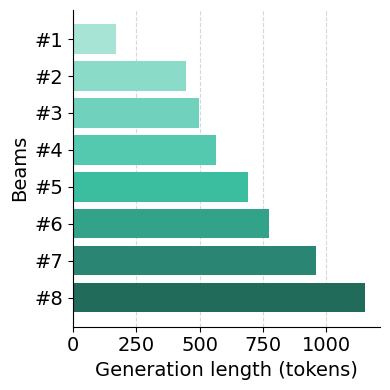

In [4]:
df_sorted = df.sort_values('token_length', ascending=True).reset_index(drop=True)

base_rgb = np.array(to_rgb('#3cc2a4'))
n = len(df_sorted)
# shorter -> shallower (blend toward white); longer -> darker (blend toward black)
# factor in [-0.55, +0.45]: negative lightens, positive darkens
factors = np.linspace(-0.55, 0.45, n)
colors = []
for f in factors:
    if f < 0:
        c = base_rgb + (1.0 - base_rgb) * (-f)
    else:
        c = base_rgb * (1.0 - f)
    colors.append(np.clip(c, 0, 1))

fig, ax = plt.subplots(figsize=(4, 4))
y_pos = np.arange(n)
ax.barh(y_pos, df_sorted['token_length'].values, color=colors, edgecolor='none')
ax.set_yticks(y_pos)
ax.set_yticklabels([f'#{i+1}' for i in range(n)], fontsize = 14)
ax.tick_params(axis='both', labelsize=14)
ax.invert_yaxis()  # #1 (shortest) on top
ax.set_xlabel('Generation length (tokens)', fontsize = 14)
ax.set_ylabel('Beams', fontsize = 14)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'attn_parallelism_beam_length.png'), dpi=300, bbox_inches='tight')
plt.show()

## Plot 2: SM utilization over decoding time (step drops as beams finish)

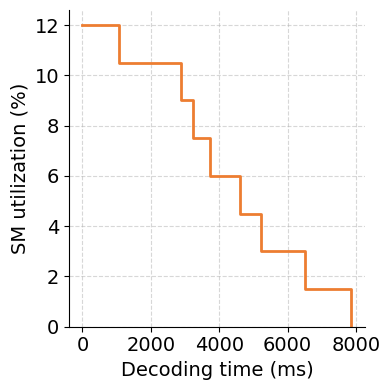

Beam finish times (ms): [1059.305034   2888.546473   3244.77031897 3727.15218598 4616.61715602
 5227.076446   6525.37792601 7871.117517  ]
Final utilization: 0.0


In [5]:
PER_BEAM_UTIL = 1.5  # per-beam SM utilization (%)

finish_times = np.sort(df['gen_time_ms'].values)
n_beams = len(finish_times)

# Step curve: start with all beams active, drop by PER_BEAM_UTIL at each finish time
xs = [0.0]
ys = [n_beams * PER_BEAM_UTIL]
current_util = n_beams * PER_BEAM_UTIL
for t in finish_times:
    xs.append(t)
    ys.append(current_util)
    current_util -= PER_BEAM_UTIL
    xs.append(t)
    ys.append(current_util)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xs, ys, color='#ed7d31', linewidth=2)
ax.set_xlabel('Decoding time (ms)', fontsize = 14)
ax.set_ylabel('SM utilization (%)', fontsize = 14)
ax.tick_params(axis='both', labelsize = 14)
ax.grid(linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'attn_parallelism_sm_utilization.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Beam finish times (ms):', finish_times)
print('Final utilization:', ys[-1])